# Candidate Test 2022 Analysis Part 1

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2).

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:
- Age of the candidates grouped by parties.
- An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.
- Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.
- Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



# Danish Election Candidate Analysis

This notebook analyzes responses from Danish election candidates collected by DR and TV2.  
The goal is to explore ideological patterns across parties and evaluate whether party affiliation can be predicted based on responses to political questions.

The analysis includes:

1. Data cleaning and preparation
2. Age distribution across parties
3. Candidate confidence in answers
4. Inter-party and intra-party disagreement
5. Classification models predicting party affiliation
6. Identification of candidates potentially closer to another party


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.preprocessing import LabelEncoder
from scipy.spatial.distance import pdist, squareform


In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Loading datasets


In [4]:
all_df = pd.read_excel("alldata.xlsx")
dr_df = pd.read_excel("drdata.xlsx")
tv2_df = pd.read_excel("tv2data.xlsx")

drq_df = pd.read_excel("drq.xlsx")
tv2q_df = pd.read_excel("tv2q.xlsx")

elected_df = pd.read_excel("electeddata.xlsx")

party_colors = {
    "Socialdemokratiet": "#b3201d",
    "Radikale Venstre": "#7c3a8d",
    "Det Konservative Folkeparti": "#9dbb21",
    "Nye Borgerlige": "#0d4c59",
    "Socialistisk Folkeparti": "#e0007a",
    "Liberal Alliance": "#31b7c2",
    "Kristendemokraterne": "#bfbfbf",
    "Moderaterne": "#6a3ddb",
    "Dansk Folkeparti": "#e7c23a",
    "Frie Grønne, Danmarks Nye Venstrefløjsparti": "#19a64a",
    "Venstre": "#006b9a",
    "Danmarksdemokraterne": "#7eaee0",
    "Enhedslisten": "#f28c18",
    "Alternativet": "#3b9a3f",
    "Løsgænger": "#666666"
}

## Initial data inspection


In [5]:
print("Shape:", all_df.shape)
display(all_df.head())
display(all_df.info())


Shape: (867, 53)


,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 867 entries, 0 to 866
Data columns (total 53 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   530        867 non-null    int64 
 1   531        867 non-null    int64 
 2   533        867 non-null    int64 
 3   534        867 non-null    int64 
 4   535        867 non-null    int64 
 5   537        867 non-null    int64 
 6   538        867 non-null    int64 
 7   540        867 non-null    int64 
 8   541        867 non-null    int64 
 9   543        867 non-null    int64 
 10  544        867 non-null    int64 
 11  545        867 non-null    int64 
 12  546        867 non-null    int64 
 13  547        867 non-null    int64 
 14  548        867 non-null    int64 
 15  550        867 non-null    int64 
 16  551        867 non-null    int64 
 17  552        867 non-null    int64 
 18  553        867 non-null    int64 
 19  555        867 non-null    int64 
 20  556        867 non-null    int64

None

In [6]:
all_df.columns


Index(['530', '531', '533', '534', '535', '537', '538', '540', '541', '543',
       '544', '545', '546', '547', '548', '550', '551', '552', '553', '555',
       '556', '557', '559', '561', '563', 'navn', 'parti', '1a', '1b', '2a',
       '2b', '3a', '3b', '4a', '4b', '5a', '5b', '6a', '6b', '7a', '7b', '8a',
       '8b', '9a', '9b', '10a', '10b', '11a', '11b', '12a', '12b', 'storkreds',
       'alder'],
      dtype='object')

### Interpretation

The dataset contains candidate-level information such as party affiliation, age, and responses to political statements. Each row represents one candidate.

The inspection step helps verify that the data has been loaded correctly and allows us to identify potential issues such as missing values or unusual entries before starting the analysis.


## Data cleaning

Some datasets contain age values equal to 0. These are treated as missing values, since they do not represent valid ages.


In [7]:
all_df["alder"] = all_df["alder"].replace(0, np.nan)
elected_df["alder"] = elected_df["alder"].replace(0, np.nan)
tv2_df["alder"] = tv2_df["alder"].replace(0, np.nan)


In [8]:
all_df.isna().sum().sort_values(ascending=False)


alder        16
1a            0
2a            0
2b            0
3a            0
3b            0
4a            0
4b            0
5a            0
5b            0
6a            0
6b            0
7a            0
7b            0
8a            0
8b            0
9a            0
9b            0
10a           0
10b           0
11a           0
11b           0
12a           0
12b           0
storkreds     0
1b            0
530           0
531           0
navn          0
533           0
534           0
535           0
537           0
538           0
540           0
541           0
543           0
544           0
545           0
546           0
547           0
548           0
550           0
551           0
552           0
553           0
555           0
556           0
557           0
559           0
561           0
563           0
parti         0
dtype: int64

## Identifying response features


In [9]:
meta_cols = ["navn", "parti", "storkreds", "alder"]
feature_cols = [c for c in all_df.columns if c not in meta_cols]

print("Number of response features:", len(feature_cols))
feature_cols[:10]


Number of response features: 49


['530', '531', '533', '534', '535', '537', '538', '540', '541', '543']

### Interpretation

In this step we identify which columns correspond to responses to political questions.

These response variables will later be used in the analysis to compare parties and to train classification models that attempt to predict a candidate’s party based on their answers.


## Number of candidates by party


In [10]:
party_counts = all_df["parti"].value_counts()

display(party_counts)


parti
Det Konservative Folkeparti                    98
Socialdemokratiet                              87
Venstre                                        84
Enhedslisten                                   74
Socialistisk Folkeparti                        70
Liberal Alliance                               70
Alternativet                                   67
Radikale Venstre                               67
Nye Borgerlige                                 51
Dansk Folkeparti                               49
Moderaterne                                    42
Kristendemokraterne                            42
Danmarksdemokraterne                           37
Frie Grønne, Danmarks Nye Venstrefløjsparti    26
Løsgænger                                       3
Name: count, dtype: int64

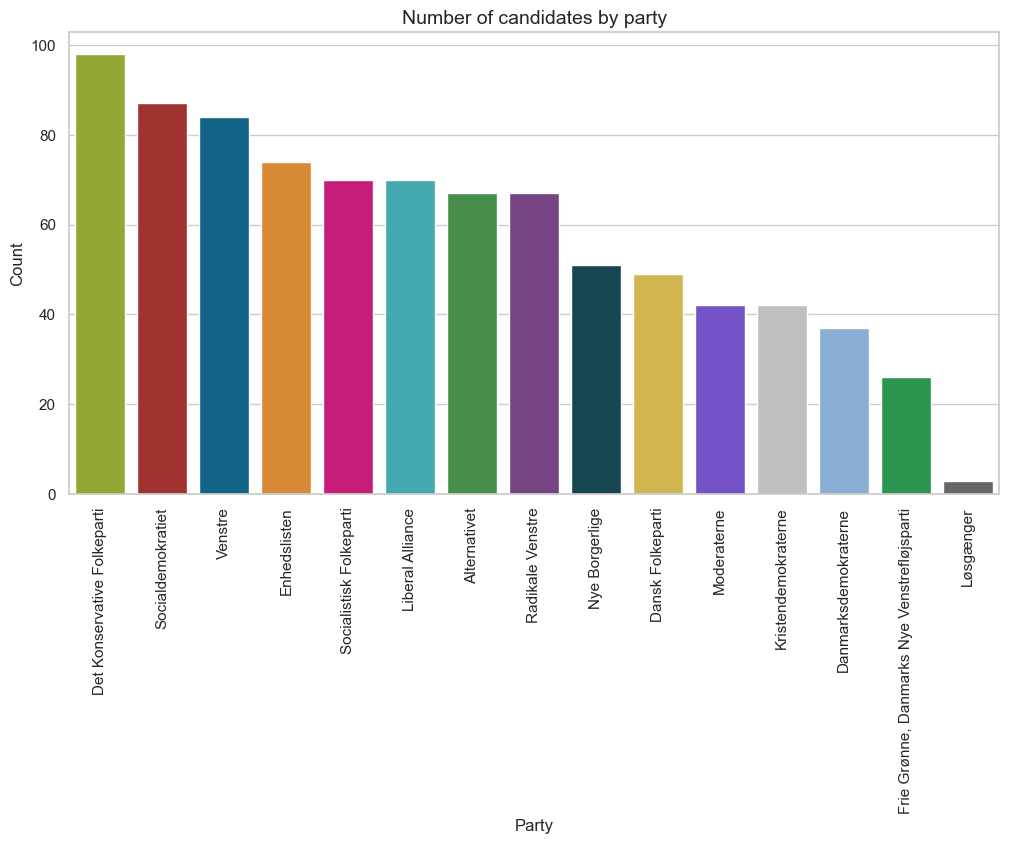

In [11]:
plt.figure(figsize=(12,6))
sns.barplot(
    x=party_counts.index,
    y=party_counts.values,
    hue=party_counts.index,
    palette=party_colors,
    legend=False
 )
plt.xticks(rotation=90)
plt.title("Number of candidates by party")
plt.ylabel("Count")
plt.xlabel("Party")
plt.show()


### Interpretation

The plot shows how candidates are distributed across parties. Some parties have noticeably more candidates than others.

This imbalance may influence later analyses and model performance.


## Age distribution across parties


In [12]:
age_summary = (
    all_df.groupby("parti")["alder"]
    .agg(["count","mean","median","min","max"])
    .sort_values("mean")
)

display(age_summary)


,count,mean,median,min,max
parti,,,,,
"Frie Grønne, Danmarks Nye Venstrefløjsparti",26,34.807692,33.0,20.0,62.0
Liberal Alliance,68,37.970588,37.0,18.0,72.0
Socialistisk Folkeparti,69,41.521739,42.0,20.0,68.0
Enhedslisten,71,42.225352,41.0,19.0,74.0
Moderaterne,42,44.261905,45.0,19.0,78.0
Det Konservative Folkeparti,94,44.723404,48.0,20.0,66.0
Radikale Venstre,67,44.955224,45.0,21.0,76.0
Socialdemokratiet,85,45.388235,45.0,20.0,78.0
Dansk Folkeparti,49,45.530612,47.0,20.0,75.0


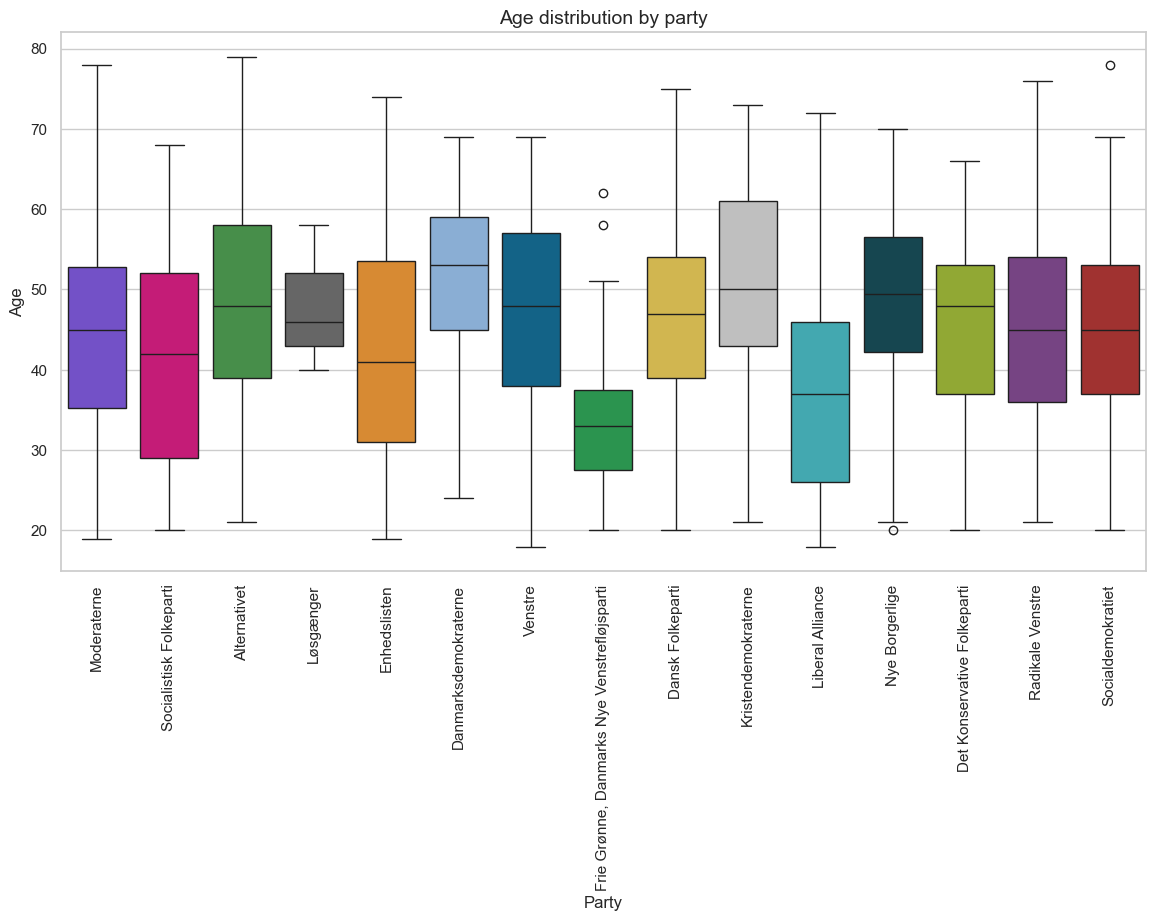

In [13]:
plt.figure(figsize=(14,7))

sns.boxplot(
    data=all_df,
    x="parti",
    y="alder",
    hue="parti",
    palette=party_colors,
    legend=False
 )

plt.xticks(rotation=90)
plt.title("Age distribution by party")
plt.xlabel("Party")
plt.ylabel("Age")

plt.show()


### Interpretation

The boxplot illustrates how candidate ages vary across political parties.

While the overall age distribution appears relatively similar across most parties, there are visible differences in median ages and the spread of values. Some parties appear to have slightly younger candidates, while others show a wider range of ages.

Outliers are also visible, indicating candidates who are significantly younger or older than the typical candidate within their party.


## Candidate confidence

Confidence is defined as the proportion of extreme answers ("strongly agree" or "strongly disagree").


In [14]:
all_df["confidence_score"] = (all_df[feature_cols].abs() == 2).mean(axis=1)

In [15]:
# Top confident candidates: 

top_confident = (
    all_df[["navn","parti","confidence_score"]]
    .sort_values("confidence_score", ascending=False)
)

display(top_confident.head(15))


,navn,parti,confidence_score
505,Sarah Nørris,Enhedslisten,1.000000
88,Søren Vanting,Det Konservative Folkeparti,1.000000
559,Kim Andkjær Doberck,Nye Borgerlige,0.897959
152,Rashid Ali,"Frie Grønne, Danmarks Nye Venstrefløjsparti",0.877551
44,Mohamed Abdikarim,"Frie Grønne, Danmarks Nye Venstrefløjsparti",0.877551
503,Jan Filbært,Enhedslisten,0.857143
151,Elise Bjerkrheim,"Frie Grønne, Danmarks Nye Venstrefløjsparti",0.857143
284,John Bjerg,Nye Borgerlige,0.857143
437,Lone Vase Langballe,Dansk Folkeparti,0.857143
359,Frank Sørensen,Dansk Folkeparti,0.857143


In [16]:
# Confidence by party:

party_conf = (
    all_df.groupby("parti")["confidence_score"]
    .mean()
    .sort_values(ascending=False)
)

display(party_conf)


parti
Frie Grønne, Danmarks Nye Venstrefløjsparti    0.748038
Enhedslisten                                   0.637066
Nye Borgerlige                                 0.625450
Løsgænger                                      0.585034
Socialistisk Folkeparti                        0.555394
Liberal Alliance                               0.523615
Alternativet                                   0.508681
Dansk Folkeparti                               0.483132
Kristendemokraterne                            0.459184
Det Konservative Folkeparti                    0.449396
Danmarksdemokraterne                           0.439051
Radikale Venstre                               0.346330
Moderaterne                                    0.297376
Socialdemokratiet                              0.267886
Venstre                                        0.266278
Name: confidence_score, dtype: float64

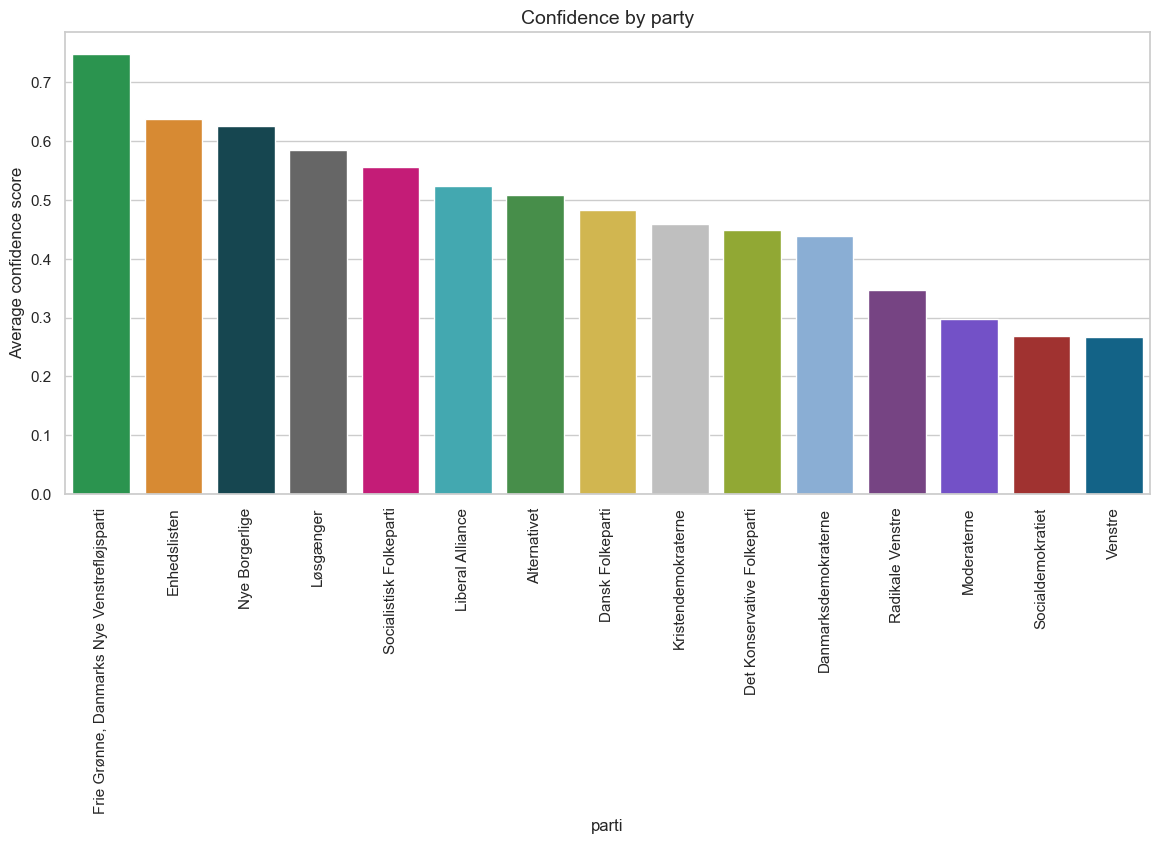

In [17]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=party_conf.index,
    y=party_conf.values,
    hue=party_conf.index,
    palette=party_colors,
    legend=False
 )

plt.xticks(rotation=90)
plt.ylabel("Average confidence score")
plt.title("Confidence by party")

plt.show()


### Interpretation

Candidate confidence measures how often a candidate gives strong answers ("strongly agree" or "strongly disagree") instead of neutral responses.

A higher confidence score suggests that a candidate takes clearer positions on political issues, while lower values indicate more moderate or uncertain responses.


## Average response profiles by party


In [18]:
party_profiles = all_df.groupby("parti")[feature_cols].mean()


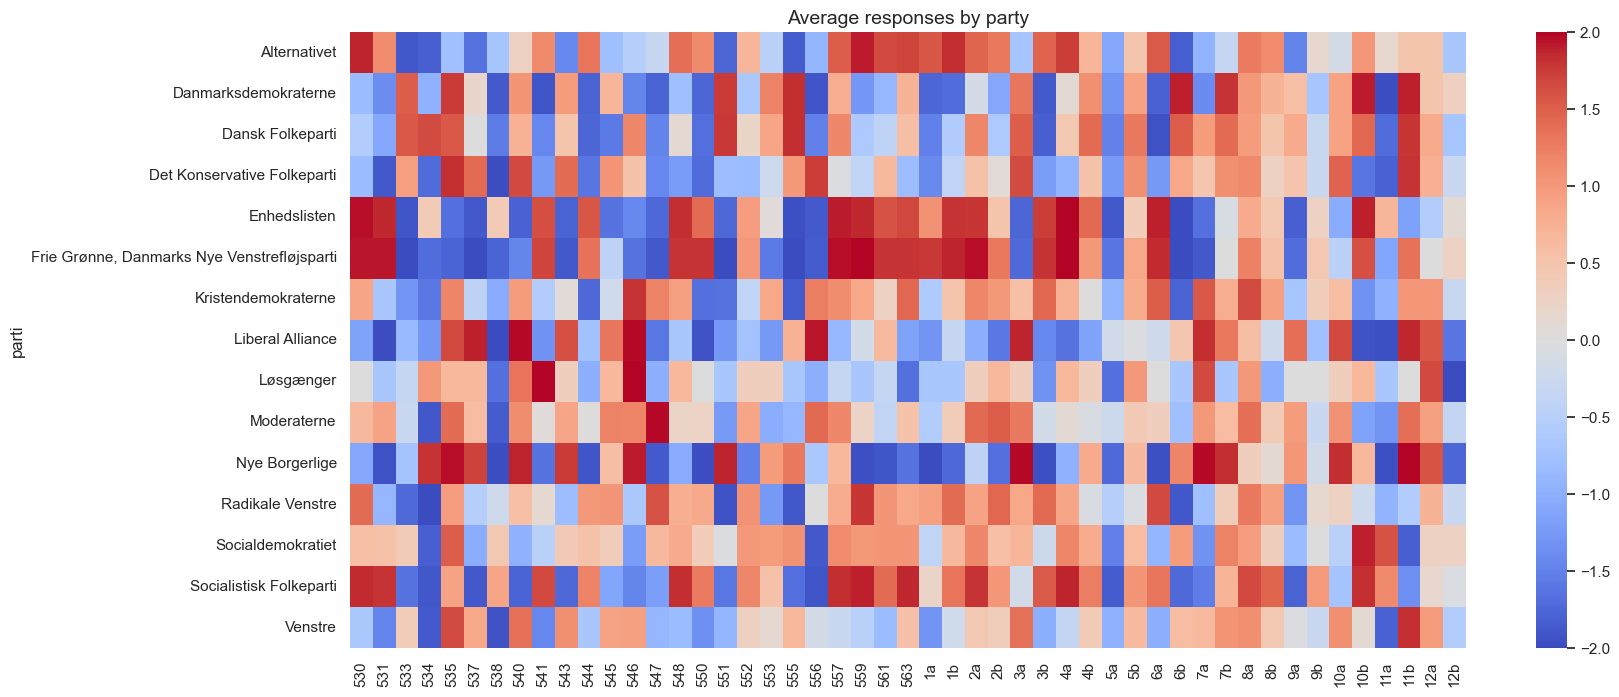

In [19]:
# Heatmap 

plt.figure(figsize=(18,8))

sns.heatmap(
    party_profiles,
    cmap="coolwarm",
    center=0
)

plt.title("Average responses by party")

plt.show()


### Interpretation

The average response profile shows how parties differ in their overall positions on political questions.

By averaging responses for each party, we can observe general ideological tendencies and compare how parties position themselves relative to each other across different issues.


## Ideological distance between parties

Inter-Party Distance

In [20]:
party_distance = pd.DataFrame(
    squareform(pdist(party_profiles.values, metric="cityblock")),
    index=party_profiles.index,
    columns=party_profiles.index
)


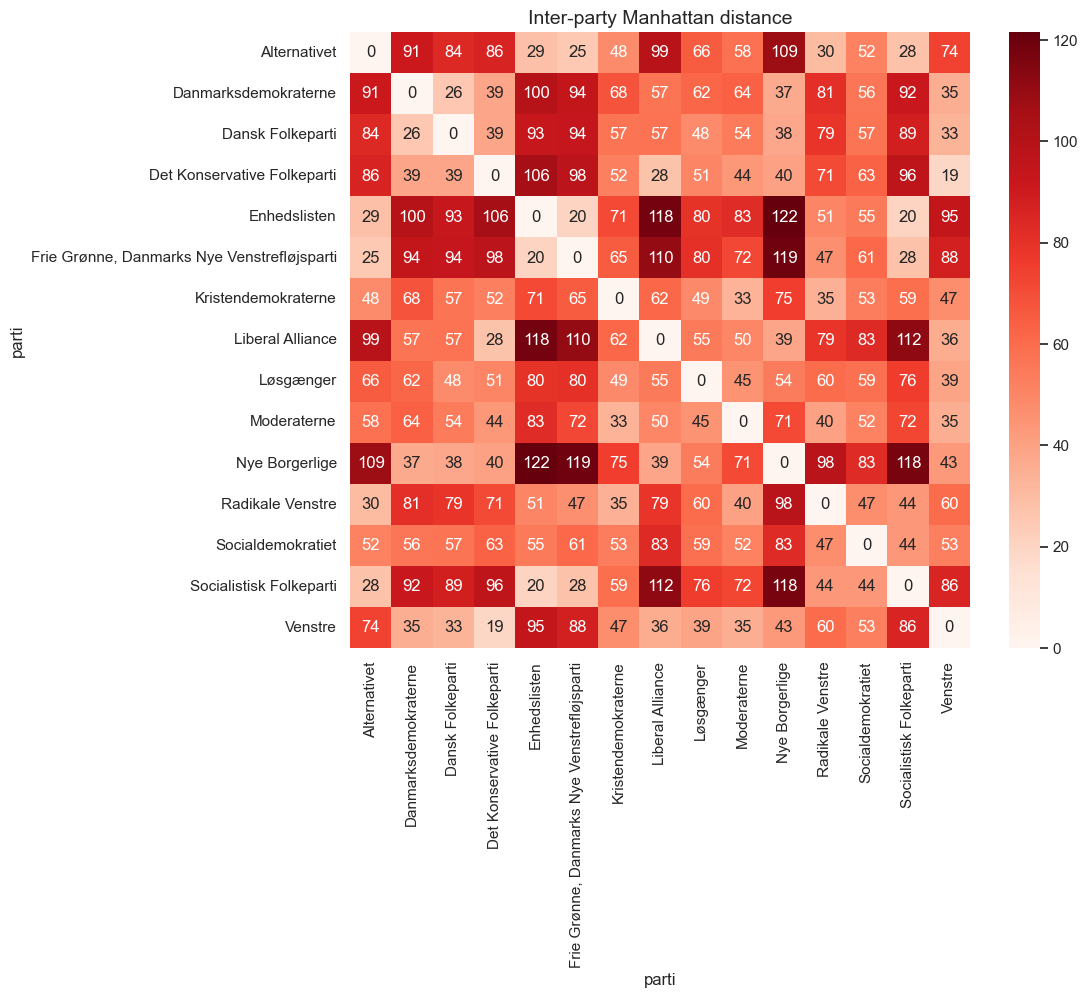

In [21]:
plt.figure(figsize=(10,8))

sns.heatmap(
    party_distance,
    cmap="Reds",
    annot=True,
    fmt=".0f"
)

plt.title("Inter-party Manhattan distance")

plt.show()


### Interpretation

The heatmap shows ideological distances between parties based on their average responses.

Smaller values indicate parties with more similar policy positions, while larger values suggest greater ideological differences.


## Internal disagreement within parties

Intra-Party Disagreement

In [22]:
intra_party = {}

for party, group in all_df.groupby("parti"):

    X = group[feature_cols].to_numpy()

    if len(group) > 1:
        intra_party[party] = pdist(X, metric="cityblock").mean()
    else:
        intra_party[party] = np.nan

intra_party = pd.Series(intra_party).sort_values(ascending=False)

display(intra_party)


Løsgænger                                      86.000000
Kristendemokraterne                            50.545877
Moderaterne                                    44.457607
Alternativet                                   43.701493
Det Konservative Folkeparti                    43.044183
Dansk Folkeparti                               42.413265
Radikale Venstre                               41.873360
Venstre                                        39.801205
Socialdemokratiet                              39.359530
Liberal Alliance                               33.959006
Enhedslisten                                   30.305072
Frie Grønne, Danmarks Nye Venstrefløjsparti    29.387692
Socialistisk Folkeparti                        29.155694
Danmarksdemokraterne                           26.081081
Nye Borgerlige                                 20.461176
dtype: float64

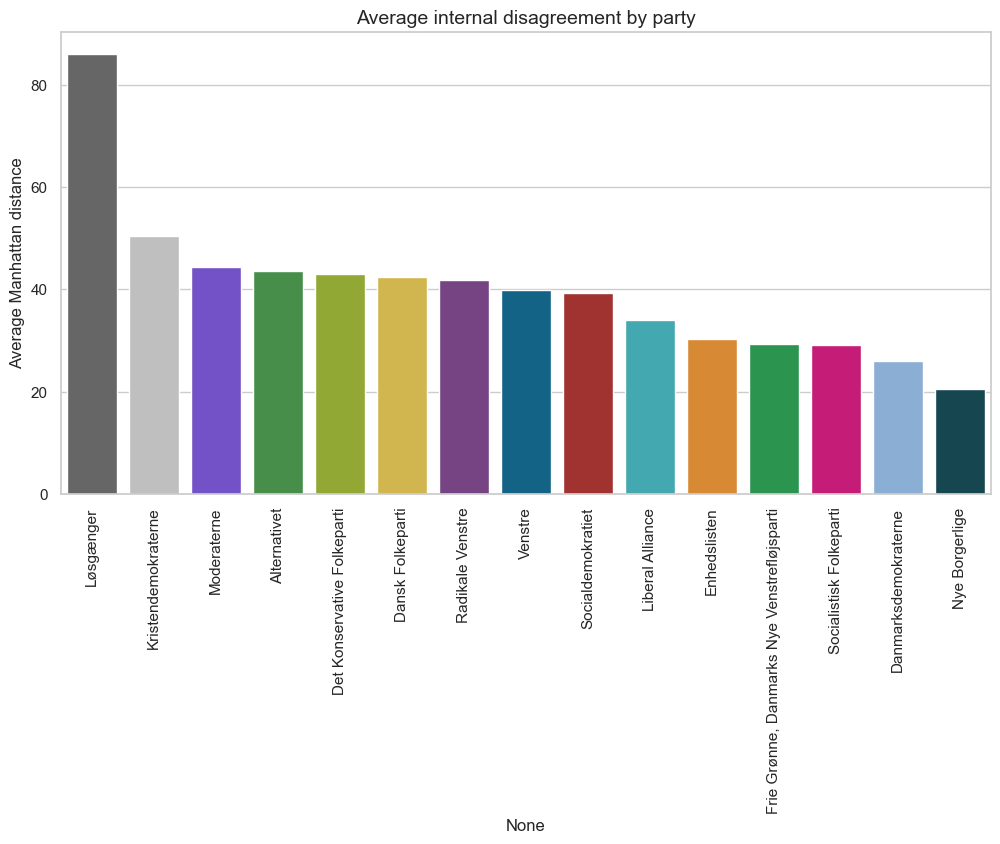

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=intra_party.index,
    y=intra_party.values,
    hue=intra_party.index,
    palette=party_colors,
    legend=False
)

plt.xticks(rotation=90)

plt.title("Average internal disagreement by party")

plt.ylabel("Average Manhattan distance")

plt.show()


### Interpretation

This measure shows how much candidates within the same party disagree in their responses.

Higher values indicate more internal diversity, while lower values suggest more consistent party positions.


## Preparing data for classification models


In [24]:
model_df = all_df[all_df["parti"] != "Løsgænger"].copy()


In [25]:
X = model_df[feature_cols]
y = model_df["parti"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [26]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)


### Interpretation

Before training machine learning models, the dataset must be prepared by selecting relevant features and separating the input variables from the target variable (party affiliation).

This step ensures that the models receive the correct information and that the data is structured properly for training and evaluation.


## Classification models

### Models:

In [27]:
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

gbt_model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=200,
    random_state=42
)


### Model Evaluation Function

In [28]:
def evaluate(model, name):

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    macro = f1_score(y_test, pred, average="macro")

    print(name)
    print("Accuracy:", acc)
    print("Macro F1:", macro)

    print(classification_report(y_test, pred, target_names=le.classes_))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        display_labels=le.classes_,
        xticks_rotation=90
    )

    plt.title(name)

    plt.show()


### Run Models

#### Note

In this step multiple classification models are trained using the prepared dataset.

The goal is to evaluate how well different machine learning approaches can predict a candidate’s party affiliation based on their responses to political questions.


Decision Tree
Accuracy: 0.7687861271676301
Macro F1: 0.7674176041300557
                                             precision    recall  f1-score   support

                               Alternativet       0.57      0.57      0.57        14
                       Danmarksdemokraterne       1.00      0.86      0.92         7
                           Dansk Folkeparti       0.77      1.00      0.87        10
                Det Konservative Folkeparti       0.78      0.35      0.48        20
                               Enhedslisten       0.94      1.00      0.97        15
Frie Grønne, Danmarks Nye Venstrefløjsparti       0.50      0.80      0.62         5
                        Kristendemokraterne       0.75      0.38      0.50         8
                           Liberal Alliance       0.76      0.93      0.84        14
                                Moderaterne       0.89      1.00      0.94         8
                             Nye Borgerlige       0.90      0.90      0.90   

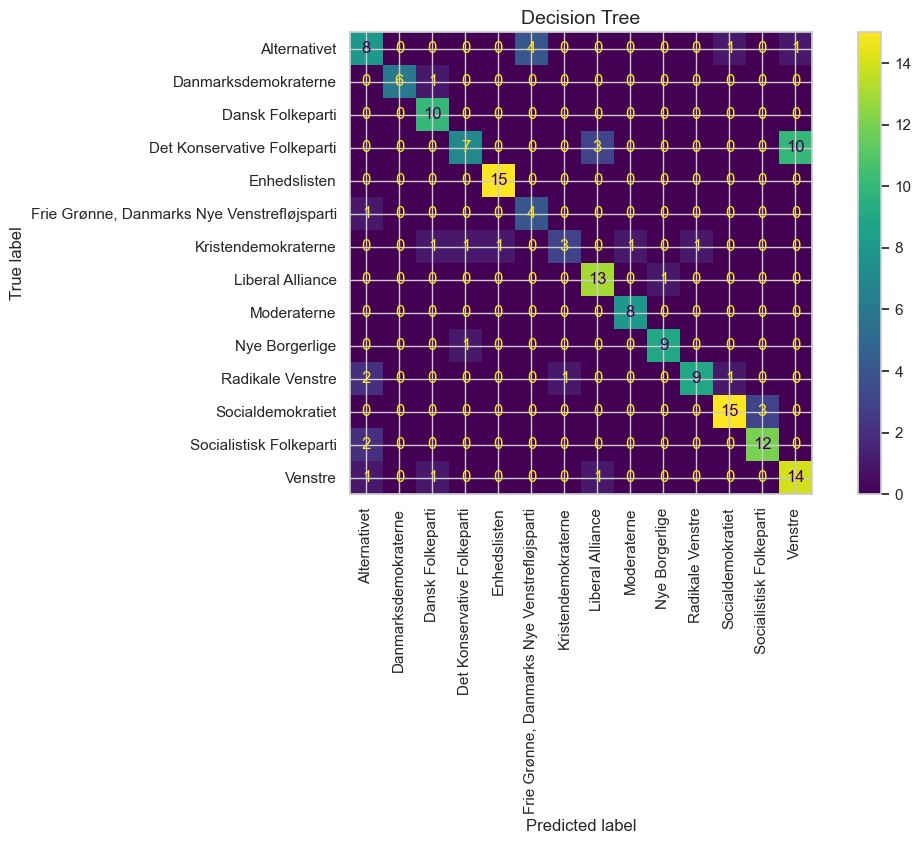

Random Forest
Accuracy: 0.9248554913294798
Macro F1: 0.9198271352006903
                                             precision    recall  f1-score   support

                               Alternativet       0.87      0.93      0.90        14
                       Danmarksdemokraterne       1.00      1.00      1.00         7
                           Dansk Folkeparti       0.91      1.00      0.95        10
                Det Konservative Folkeparti       0.94      0.85      0.89        20
                               Enhedslisten       1.00      1.00      1.00        15
Frie Grønne, Danmarks Nye Venstrefløjsparti       1.00      0.60      0.75         5
                        Kristendemokraterne       1.00      0.75      0.86         8
                           Liberal Alliance       0.82      1.00      0.90        14
                                Moderaterne       0.89      1.00      0.94         8
                             Nye Borgerlige       1.00      1.00      1.00   

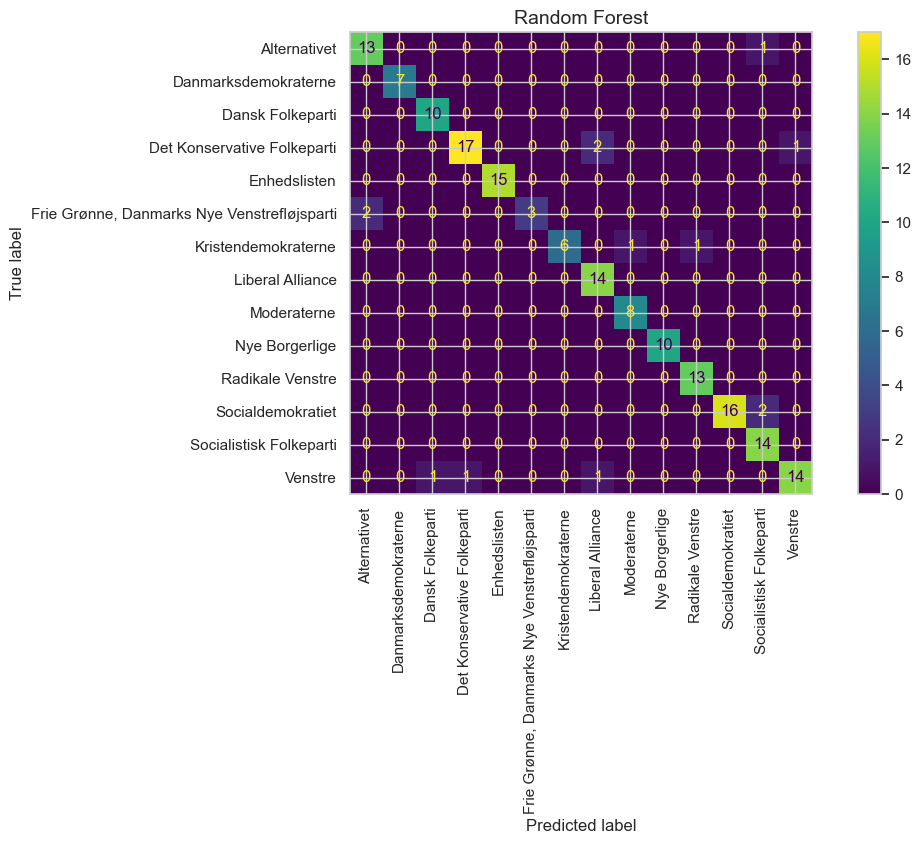

Gradient Boosted Tree
Accuracy: 0.9075144508670521
Macro F1: 0.8999557215040142
                                             precision    recall  f1-score   support

                               Alternativet       0.87      0.93      0.90        14
                       Danmarksdemokraterne       1.00      0.86      0.92         7
                           Dansk Folkeparti       0.91      1.00      0.95        10
                Det Konservative Folkeparti       0.95      0.90      0.92        20
                               Enhedslisten       1.00      0.93      0.97        15
Frie Grønne, Danmarks Nye Venstrefløjsparti       0.80      0.80      0.80         5
                        Kristendemokraterne       1.00      0.62      0.77         8
                           Liberal Alliance       0.88      1.00      0.93        14
                                Moderaterne       0.89      1.00      0.94         8
                             Nye Borgerlige       1.00      0.90     

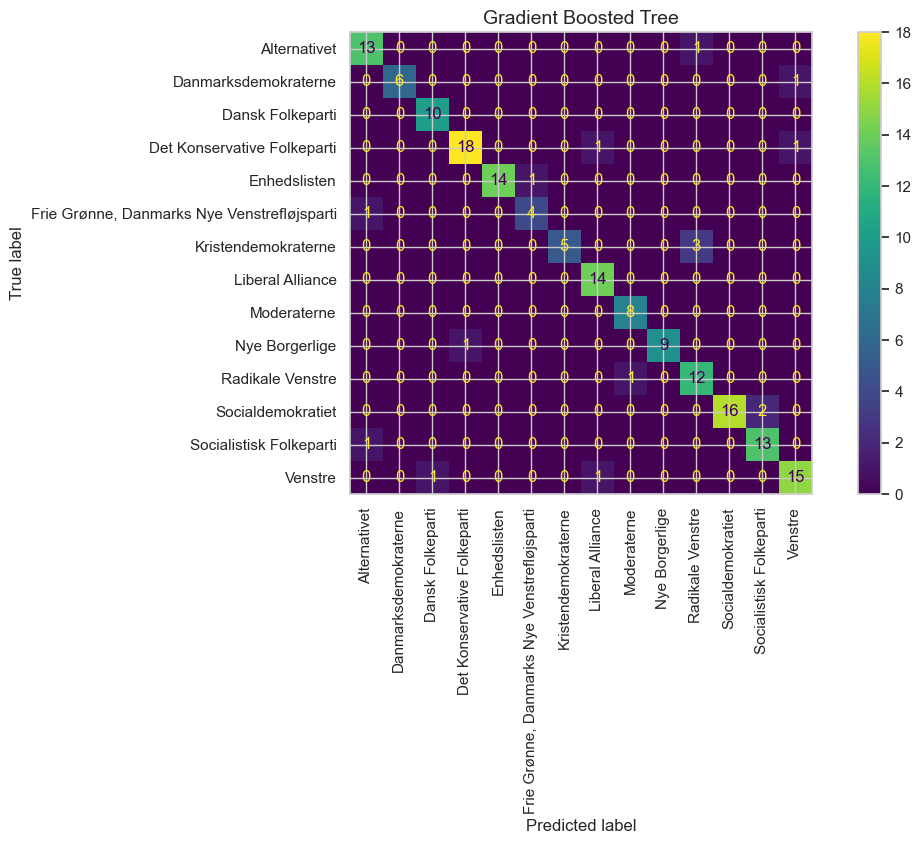

In [29]:
evaluate(dt_model, "Decision Tree")

evaluate(rf_model, "Random Forest")

evaluate(gbt_model, "Gradient Boosted Tree")


## Cross-validation comparison


In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosted Tree": gbt_model
}

results = []

for name, model in models.items():

    scores = cross_val_score(model, X, y_encoded, cv=cv)

    results.append({
        "model": name,
        "mean_accuracy": scores.mean(),
        "std": scores.std()
    })

cv_results = pd.DataFrame(results).sort_values("mean_accuracy", ascending=False)

display(cv_results)


,model,mean_accuracy,std
1,Random Forest,0.900470,0.029540
2,Gradient Boosted Tree,0.879688,0.032450
0,Decision Tree,0.704900,0.022375


### Interpretation

The cross-validation results show that ensemble models perform better than a single Decision Tree.

Random Forest achieves the highest mean accuracy (~0.90), followed by Gradient Boosted Trees (~0.88), while the single Decision Tree performs significantly worse (~0.70).

This suggests that combining multiple trees improves the model’s ability to capture patterns in the data and generalize better.

The relatively small standard deviations indicate that the model performance is stable across the cross-validation folds.


## Feature importance


In [31]:
rf_model.fit(X_train, y_train)

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance.head(15))


,feature,importance
3,534,0.058757
20,556,0.049507
13,547,0.048553
46,11b,0.040796
44,10b,0.040510
1,531,0.036766
35,6a,0.036553
12,546,0.032996
37,7a,0.032170
4,535,0.031592


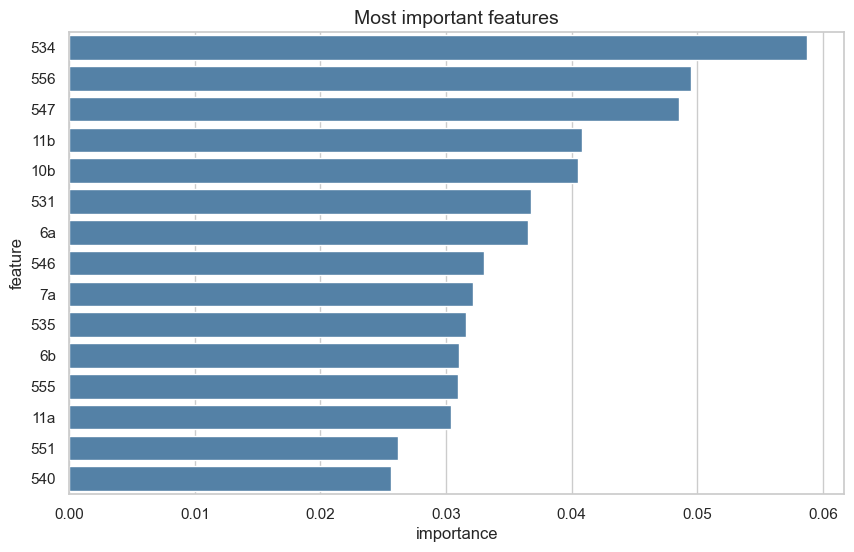

In [32]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature",
    color="steelblue"
)

plt.title("Most important features")

plt.show()


### Interpretation

Feature importance indicates which political questions are most influential in predicting a candidate's party affiliation.

The Random Forest model evaluates how much each feature contributes to reducing classification error. Features with higher importance scores have greater influence in distinguishing between parties.

These results help identify which policy issues are most politically differentiating among candidates and therefore most useful for predicting party membership.


## Candidates potentially closer to another party


In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pred = cross_val_predict(
    rf_model,
    X,
    y_encoded,
    cv=cv,
    method="predict"
)

rf_proba = cross_val_predict(
    rf_model,
    X,
    y_encoded,
    cv=cv,
    method="predict_proba"
)


In [34]:
wrong_party = model_df[["navn","parti"]].copy()

wrong_party["predicted_party"] = le.inverse_transform(rf_pred)

wrong_party["correct"] = wrong_party["parti"] == wrong_party["predicted_party"]

wrong_party["true_party_prob"] = rf_proba[np.arange(len(model_df)), y_encoded]

display(
    wrong_party.sort_values("true_party_prob")
    .head(20)
)


,navn,parti,predicted_party,correct,true_party_prob
653,Finn Andersen,Kristendemokraterne,Socialdemokratiet,False,0.025976
250,Phillip Sperling,Venstre,Liberal Alliance,False,0.062417
37,Gustav Juul,Venstre,Det Konservative Folkeparti,False,0.070167
140,Bo Sandroos,Venstre,Det Konservative Folkeparti,False,0.070833
679,Mads Silberg,Det Konservative Folkeparti,Kristendemokraterne,False,0.071833
519,Kasper B. Mundt,Venstre,Dansk Folkeparti,False,0.079131
219,Nikoline Prehn,Socialdemokratiet,Socialistisk Folkeparti,False,0.093464
509,Michael Mikkelsen,Danmarksdemokraterne,Venstre,False,0.094036
224,Mette Reissmann,Socialdemokratiet,Radikale Venstre,False,0.105381
163,Jon Læssøe Stephensen,Moderaterne,Radikale Venstre,False,0.116583


### Interpretation

This analysis identifies candidates whose predicted party differs from their actual party affiliation.

Examining these cases can provide insights into cross-party similarities and highlight candidates whose policy profiles diverge from their party's typical position.


## Conclusion

This analysis explored ideological patterns among Danish election candidates using responses from the DR and TV2 candidate tests.

The exploratory analysis showed that parties differ in their response profiles and ideological distances, while some variation also exists within parties. Machine learning models were able to predict party affiliation with relatively high accuracy, suggesting that candidates’ policy responses contain strong signals about their political alignment.

Feature importance analysis also highlighted which political questions are most useful for distinguishing between parties.

Overall, the results indicate that candidate test responses can provide meaningful insights into party positioning and ideological differences within the Danish political landscape.


## Limitations

This analysis is limited by the fact that responses are self-reported and may not fully reflect candidates’ real political behavior. Furthermore, some parties have fewer candidates, which may affect model performance for those classes.